Create persistent vector store for woman shoes

In [1]:
from llama_index.core.schema import ImageNode
from llama_index.core.response.notebook_utils import display_source_node, display_image_uris
from llama_index.core.indices.multi_modal.base import MultiModalVectorStoreIndex
from llama_index.core.node_parser import SentenceSplitter
from llama_index.embeddings.clip import ClipEmbedding
from llama_index.embeddings.cohere import CohereEmbedding
from llama_index.core import VectorStoreIndex
from llama_index.vector_stores.chroma import ChromaVectorStore
from llama_index.core import StorageContext
from chromadb.utils.embedding_functions import OpenCLIPEmbeddingFunction
from chromadb.utils.data_loaders import ImageLoader
from llama_index.vector_stores.chroma import ChromaVectorStore
from dotenv import load_dotenv
from tfg_chatbot.ingestion import load_documents
import chromadb
import os

In [2]:
_ = load_dotenv(".env")

In [3]:
# Create Cohere embedding 
text_embed_model = CohereEmbedding(
    api_key=os.getenv('COHERE_API_KEY')
)

In [4]:
image_embed_model = ClipEmbedding()


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "d:\programas\miniconda\envs\ia_tfg\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "d:\programas\miniconda\envs\ia_tfg\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "d:\programas\miniconda\envs\ia_tfg\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.start()
  File "d:\progr

In [5]:
# Create a persistent client
client = chromadb.PersistentClient(path="../app/women_index_02")

# Create a multimodal collection
collection = client.get_or_create_collection(
    name="multimodal_collection_women", 
    embedding_function=OpenCLIPEmbeddingFunction(),
    data_loader=ImageLoader(),
    )

### Load images and text documents

In [6]:
image_documents, text_documents = load_documents('../data/women_txt/', '../data/women_images/')

In [7]:
print(f'Total Image Documents:', len(image_documents))
print(f'Total Text Documents:', len(image_documents))

Total Image Documents: 282
Total Text Documents: 282


In [8]:
image_documents[0].metadata

{'file_path': 'd:\\workspace\\proyecto_tfg\\tfg-chatbot\\notebooks\\..\\data\\women_images\\000893d0-18f1-4557-8d27-b9b3452829b1.jpg',
 'file_name': '000893d0-18f1-4557-8d27-b9b3452829b1.jpg',
 'file_type': 'image/jpeg',
 'file_size': 358412,
 'creation_date': '2024-12-02',
 'last_modified_date': '2024-11-27'}

In [9]:
text_documents[0].text

'Name: LEATHER STRAPPY SANDALS\r\nDescription: High heel leather sandals with metallic effect. Thin straps. Round toe. Buckled ankle strap closure. \r\n\r\nHeel height: 3.9 inches (10 cm)\r\nPrice: 89.9\r\nCurrency: USD'

In [10]:
text_documents[0].metadata

{'file_path': 'd:\\workspace\\proyecto_tfg\\tfg-chatbot\\notebooks\\..\\data\\women_txt\\000893d0-18f1-4557-8d27-b9b3452829b1.txt',
 'file_name': '000893d0-18f1-4557-8d27-b9b3452829b1.txt',
 'file_type': 'text/plain',
 'file_size': 208,
 'creation_date': '2024-12-02',
 'last_modified_date': '2024-12-02'}

### Create Multimodal VectorStore Index

In [11]:
# Define the sentence splitter
node_parser = SentenceSplitter.from_defaults()

In [12]:
# Get nodes from image documents 
image_nodes = node_parser.get_nodes_from_documents(image_documents)

In [13]:
print(image_nodes)
print(image_nodes[0].metadata['file_path'])
print(image_nodes[1].metadata['file_path'])
print(image_nodes[2].metadata['file_path'])
print(len(image_nodes))

[ImageNode(id_='f1ae23e1-4013-4019-9d00-266aeb9b339d', embedding=None, metadata={'file_path': 'd:\\workspace\\proyecto_tfg\\tfg-chatbot\\notebooks\\..\\data\\women_images\\000893d0-18f1-4557-8d27-b9b3452829b1.jpg', 'file_name': '000893d0-18f1-4557-8d27-b9b3452829b1.jpg', 'file_type': 'image/jpeg', 'file_size': 358412, 'creation_date': '2024-12-02', 'last_modified_date': '2024-11-27'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='08fce4a5-9590-477a-9ea0-cdde860368ea', node_type=<ObjectType.DOCUMENT: '4'>, metadata={'file_path': 'd:\\workspace\\proyecto_tfg\\tfg-chatbot\\notebooks\\..\\data\\women_images\\000893d0-18f1-4557-8d27-b9b3452829b1.jpg', 'file_name': '000893d0-18f1-4557-8d27-b9b3452829b1.jpg', 'f

In [14]:
# Get nodes from text documents
text_nodes = node_parser.get_nodes_from_documents(text_documents)

In [15]:
print(text_nodes)
print(text_nodes[0].metadata['file_path'])
print(text_nodes[1].metadata['file_path'])
print(text_nodes[2].metadata['file_path'])
print(len(text_nodes))

[TextNode(id_='d5a91969-880d-42d9-9d86-6fc511e1202c', embedding=None, metadata={'file_path': 'd:\\workspace\\proyecto_tfg\\tfg-chatbot\\notebooks\\..\\data\\women_txt\\000893d0-18f1-4557-8d27-b9b3452829b1.txt', 'file_name': '000893d0-18f1-4557-8d27-b9b3452829b1.txt', 'file_type': 'text/plain', 'file_size': 208, 'creation_date': '2024-12-02', 'last_modified_date': '2024-12-02'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='b153c421-7782-4635-9475-109d12be33b4', node_type=<ObjectType.DOCUMENT: '4'>, metadata={'file_path': 'd:\\workspace\\proyecto_tfg\\tfg-chatbot\\notebooks\\..\\data\\women_txt\\000893d0-18f1-4557-8d27-b9b3452829b1.txt', 'file_name': '000893d0-18f1-4557-8d27-b9b3452829b1.txt', 'file_type':

In [17]:
# Create multimodal index
index = MultiModalVectorStoreIndex(
    nodes = image_nodes + text_nodes,
    image_embed_model=image_embed_model,
    embed_model = text_embed_model
)

RuntimeError: Numpy is not available

In [11]:
# set up ChromaVectorStore and load in data with LlamaIndex 
vector_store = ChromaVectorStore(chroma_collection=collection)

In [12]:
# create storage context
storage_context = StorageContext.from_defaults(vector_store=vector_store)

### Create VectorStore Index 

In [14]:
# create index of documents
index = VectorStoreIndex.from_documents(
    documents = image_documents,
    storage_context=storage_context,
    embed_model = embeder
)

In [15]:
retriever = index.as_retriever(similarity_top_k=3)

In [16]:
retrival_result = retriever.retrieve("Slide Sandal")
retrival_result

[NodeWithScore(node=ImageNode(id_='82fe0944-d2d9-4265-86c6-d5d93a32ea3f', embedding=None, metadata={'file_path': 'd:\\workspace\\proyecto_tfg\\tfg-chatbot\\notebooks\\..\\data\\women_images\\196bfc19-7bb7-402b-a34f-9cb904cebc42.jpg', 'file_name': '196bfc19-7bb7-402b-a34f-9cb904cebc42.jpg', 'file_type': 'image/jpeg', 'file_size': 341829, 'creation_date': '2024-12-02', 'last_modified_date': '2024-11-27'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='1b6f42ed-748b-4f4b-9457-141c8feef294', node_type='4', metadata={'file_path': 'd:\\workspace\\proyecto_tfg\\tfg-chatbot\\notebooks\\..\\data\\women_images\\196bfc19-7bb7-402b-a34f-9cb904cebc42.jpg', 'file_name': '196bfc19-7bb7-402b-a34f-9cb904cebc42.jpg', 'file_

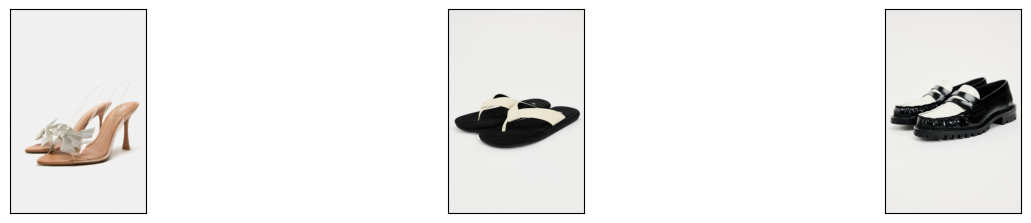

In [20]:
MAX_RES = 3 
cnt = 0
image_results = []
for r in retrival_result:
    if isinstance(r.node, ImageNode):
        image_results.append(r.node.metadata['file_path'])
    else:
        if cnt < MAX_RES:
            display_source_node(r)
        cnt += 1

display_image_uris(image_results, [3,3])

In [ ]:
# Define the sentence splitter
node_parser = SentenceSplitter.from_defaults()
image_nodes = node_parser.get_nodes_from_documents(image_documents)
text_nodes = node_parser.get_nodes_from_documents(text_documents)

    # Create multimodal index
    index = MultiModalVectorStoreIndex(
    nodes = image_nodes + text_nodes,
    image_embed_model=image_embed_model,
    embed_model = embed_model
    )